In [1]:
import json
import pickle
import numpy as np
from copy import deepcopy
from pymatgen.core import Structure
from pymatgen.io.ase import AseAtomsAdaptor

# for plotting if needed
import matplotlib
import matplotlib.pyplot as plt

In [2]:
import sys
from pathlib import Path
ROOT = Path.cwd().parent.parent.parent

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT)) 

from muonscripts.constants import constants

from muonscripts.io_tools.read import read_cif
from muonscripts.io_tools.read import read_from_file

from muonscripts.io_tools.load_relax import load_relax
from muonscripts.io_tools.load_relax import save_relax_results
from muonscripts.io_tools.load_relax import load_relax_results
from muonscripts.io_tools.find_qe_files import select_groups
from muonscripts.io_tools.find_qe_files import get_relax_after_run
from muonscripts.io_tools.find_qe_files import print_relax_summary
from muonscripts.io_tools.find_qe_files import load_relax_from_folder

from muonscripts.io_tools.dataframe import get_dataframe

from muonscripts.undi_tools.second_moments_avg import second_moments_fn
from muonscripts.undi_tools.second_moments import zero_field_distribution_powder

from muonscripts.undi_tools.atoms_scaling import scale_neighbors, partition_into_shells
from muonscripts.undi_tools.atoms_scaling import only_muon_cluster, compute_zeta_cluster

from muonscripts.undi_tools.atoms import build_undi_neighbors, build_undi_neighbors_from_file
from muonscripts.undi_tools.atoms import complete_undi_neighbors, neighbors_hilbert_dimension

from muonscripts.efg.point_charge import compute_efg
from muonscripts.efg.point_charge import sphere_radius_convergence
from muonscripts.efg.point_charge import build_point_charge_efg_neighbors

# from muonscripts.efg.utils import nu_Q, quadrupole_frequencies, get_omegaQ_mu
# from muonscripts.efg.point_charge import compute_efg, point_charge_EFG, diagonalize_EFG, atom_dict_EFG

from muonscripts.muon_tools.displacements import radial_to_dict
from muonscripts.muon_tools.displacements import max_displacement
from muonscripts.muon_tools.displacements import select_radial_displacement

from muonscripts.muon_tools.aiida_muon.sites_supercells import gensup
from muonscripts.muon_tools.aiida_muon.sites_supercells import niche_add_impurities
from muonscripts.muon_tools.aiida_muon.sites_supercells import compute_suggest_supercell_size

from muonscripts.muon_tools.aiida_muon.distortions import get_distortions
from muonscripts.muon_tools.aiida_muon.clustering import get_clustering_after_run_from_data

from muonscripts.muon_tools.aiida_muon.clustering_report import print_clustering_summary

from muonscripts.muesr_tools.local_fields import pfields, rfields

from muonscripts.muon_tools import contact_field

from muonscripts.muon_tools.muonic_dataframe import get_dataframe

from muonscripts.plot_tools.muon import field_bar

In [3]:
def style_axes(ax, fontsize=12):
    for spine in ax.spines.values():
        spine.set_linewidth(1.5)

    ax.minorticks_on()

    ax.tick_params(
        axis="both",
        which="major",
        direction="in",
        top=True,
        right=True,
        length=6,
        width=1.0,
        labelsize=fontsize,
    )

    ax.tick_params(
        axis="both",
        which="minor",
        direction="in",
        top=True,
        right=True,
        length=3,
        width=1.0,
    )

In [4]:
import spglib
from ase import Atoms
from collections import defaultdict
from pymatgen.core import Structure
from pymatgen.symmetry.analyzer import SpacegroupAnalyzer


def get_atom_kinds_pymatgen(structure: Structure) -> dict[str, list[int]]:
    """
    Group atoms into symmetry-equivalent kinds and label them by element.

    Args:
        structure (pymatgen.Structure): Structure to analyze.

    Returns:
        dict[str, list[int]]: Mapping from kind label to the list of
            0-based atom indices (matching `structure`) belonging to
            that symmetry-equivalent kind. The label is the plain
            element symbol (e.g. "Fe") if the structure has only one
            symmetry-inequivalent site of that element, or the symbol
            suffixed with a 1-based index (e.g. "Fe1", "Fe2", ...) if
            there are several inequivalent sites of the same element --
            matching the kind-labeling convention used in QE input files.
    """
    analyzer = SpacegroupAnalyzer(structure)
    equiv = analyzer.get_symmetry_dataset().equivalent_atoms

    # group atom indices by their representative (kind) index
    kind_dict: dict[int, list[int]] = defaultdict(list)
    for i, k in enumerate(equiv):
        kind_dict[int(k)].append(i)

    # element symbol for each kind, taken from its representative atom
    kind_symbols = {k: structure[k].specie.symbol for k in kind_dict}

    # how many distinct kinds share each element symbol
    symbol_counts: dict[str, int] = defaultdict(int)
    for sym in kind_symbols.values():
        symbol_counts[sym] += 1

    # assign labels: plain symbol if the element has only one kind,
    # else symbol + 1-based index, ordered by representative atom index
    labeled: dict[str, list[int]] = {}
    symbol_running_count: dict[str, int] = defaultdict(int)
    for k in sorted(kind_dict):
        sym = kind_symbols[k]
        if symbol_counts[sym] == 1:
            label = sym
        else:
            symbol_running_count[sym] += 1
            label = f"{sym}{symbol_running_count[sym]}"
        labeled[label] = kind_dict[k]

    return labeled


def _label_kinds(kind_symbols: dict[int, str]) -> dict[int, str]:
    """Helper to generate distinct labels for symmetry kinds.
    
    If an element appears in multiple symmetry kinds, it appends a 1-based index 
    (e.g., 'Fe1', 'Fe2'). If it only appears once, it stays plain (e.g., 'O').
    """
    # Count how many times each element symbol appears across all kinds
    symbol_counts = defaultdict(int)
    for symbol in kind_symbols.values():
        symbol_counts[symbol] += 1
        
    # Generate labels
    labels = {}
    current_indices = defaultdict(int)
    
    for kind_id, symbol in kind_symbols.items():
        if symbol_counts[symbol] > 1:
            current_indices[symbol] += 1
            labels[kind_id] = f"{symbol}{current_indices[symbol]}"
        else:
            labels[kind_id] = symbol
            
    return labels


def get_atom_kinds_ase(atoms: Atoms, symprec: float = 1e-3) -> dict[str, list[int]]:
    """
    Group atoms into symmetry-equivalent kinds and label them by element.

    ASE equivalent of `get_atom_kinds_pymatgen`, using spglib directly
    since ASE has no built-in symmetry-equivalence finder.

    Args:
        atoms (ase.Atoms): Structure to analyze.
        symprec (float): Symmetry-detection tolerance passed to spglib.

    Returns:
        dict[str, list[int]]: Mapping from kind label to the list of
            0-based atom indices (matching `atoms`) belonging to that
            symmetry-equivalent kind. Label is the plain element symbol
            if unique, else symbol + 1-based index (e.g. "Fe1", "Fe2").

    Raises:
        RuntimeError: If spglib fails to determine the symmetry dataset
            (e.g. an invalid or degenerate cell).
    """
    cell = (
        atoms.get_cell()[:],
        atoms.get_scaled_positions(),
        atoms.get_atomic_numbers(),
    )
    dataset = spglib.get_symmetry_dataset(cell, symprec=symprec)

    if dataset is None:
        raise RuntimeError(
            "spglib could not determine a symmetry dataset for this "
            f"structure at symprec={symprec}."
        )

    # spglib >=2.5 returns a dataclass-like SpglibDataset; older returns dict
    equiv = (
        dataset.equivalent_atoms
        if hasattr(dataset, "equivalent_atoms")
        else dataset["equivalent_atoms"]
    )

    symbols = atoms.get_chemical_symbols()

    kind_dict: dict[int, list[int]] = defaultdict(list)
    for i, k in enumerate(equiv):
        kind_dict[int(k)].append(i)

    kind_symbols = {k: symbols[k] for k in kind_dict}
    labels = _label_kinds(kind_symbols)

    return {labels[k]: indices for k, indices in kind_dict.items()}

In [5]:
import os
dpath='./'

In [6]:
filename = 'Fe2P.cif'
filename = os.path.join(dpath, filename)
st = Structure.from_file(filename)

/home/misah/.virtualenvs/pyqm/lib/python3.10/site-packages/pymatgen/core/structure.py:3109: UserWarning: Issues encountered while parsing CIF: 2 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]


In [7]:
sc_matrix = [
    [2, 0, 0], 
    [0, 2, 0], 
    [0, 0, 3]
    ]

In [8]:
preview = True

pattern="*.out"
check_input = True
calc_types = "relax"

folder = os.path.join(dpath, 'query/relax')

if preview:
    groups = get_relax_after_run(
        folder, 
        pattern=pattern, 
        check_input=check_input,
        calc_types=calc_types, 
        verbose=False,
    )
    print(f"\nPreview: {len(groups)} system group(s) found "
            f"(selection filters ignored in preview mode)\n")
    print_relax_summary(groups)


results = load_relax(
    path=folder,
    pattern=pattern,
    check_input=check_input,
    calc_types=calc_types,
    group_by_system=True,
    pymatgen=True,
    verbose=True,
    # **select_kwargs
)

file = 'Fe2P_muonrelax.pkl'
file = os.path.join(dpath, file)
save_relax_results(results, file, fmt='pickle')


Preview: 1 system group(s) found (selection filters ignored in preview mode)

  Fe-H-P  nat = 109  ntyp = 3  -> 11 converged runs
  ------------------------------------
  1 distinct system(s), 11 converged run(s) total
Saved 11 result(s) to Fe2P_muonrelax.pkl (pickle)


In [9]:
input_st = st.copy()
init_supc = input_st.copy()
init_supc.make_supercell(sc_matrix)

cluster = get_clustering_after_run_from_data(
    results, 
    input_st, 
    sc_matrix, 
    magmom=None
)

print('The cluster keys are:', list(cluster.keys()))

mapping = cluster["mapping"]
unique_cluster = cluster["unique_pos"]

unique_cluster

unique_sorted = {v: i+1 for i, v in enumerate(sorted(set(mapping)))}
remapped = [unique_sorted[x] for x in mapping]

remapped, remapped

print_clustering_summary(
    cluster, 
    input_st=input_st,   # or None, if you want the supercell positions
    use_unitcell=True,   # or None, if you want the supercell positions
    # precision=5
)

The cluster keys are: ['unique_pos', 'mag_inequivalent', 'mapping']

UNIQUE MUON SITES (unitcell frac. coordinates)
  #        idx        frac_x        frac_y        frac_z       dE (eV)
----------------------------------------------------------------------
  0         r2       0.00227       0.32766       0.50307       0.00000
  1         r5       0.00004       0.70607       0.00022       0.27780
  2        r10       0.29240       0.29242       0.00325       0.27822
  3        r11       0.33195       0.66478       0.50308       0.66880
  4         r3       0.00000       0.54392       0.00905       0.76351
  5         r1       0.00000       0.00001       0.00006       1.15513
----------------------------------------------------------------------
Total unique sites: 6

MAGNETICALLY INEQUIVALENT SITES PENDING CALCULATION (0) (unitcell frac. coordinates)
  (none -- all magnetically inequivalent sites already covered)


In [10]:
unique_cluster[0].keys()

dict_keys(['idx', 'rlxd_struct', 'energy'])

In [11]:
df, df_all = get_dataframe(unique_cluster, sc_matrix)
print(df_all)

  structure_id label     tot_energy       muon_position_sc  \
1           r2     A -349824.943494  [0.001, 0.164, 0.167]   
2           r5     B  -349824.66569      [0.0, 0.354, 0.0]   
3          r10     C -349824.665278  [0.146, 0.146, 0.001]   
4          r11     D -349824.274692  [0.166, 0.333, 0.167]   
5           r3     E -349824.179979    [0.0, 0.272, 0.003]   
6           r1     F -349823.788364        [0.0, 0.0, 0.0]   

        muon_position_uc delta_E  
1  [0.002, 0.328, 0.501]       0  
2      [0.0, 0.708, 0.0]     277  
3  [0.292, 0.292, 0.003]     278  
4  [0.332, 0.666, 0.501]     668  
5    [0.0, 0.544, 0.009]     763  
6        [0.0, 0.0, 0.0]    1155  


In [12]:
print(df)

  structure_id label          muon_position delta_E_meV
1           r2     A  [0.002, 0.328, 0.501]           0
2           r5     B      [0.0, 0.708, 0.0]         277
3          r10     C  [0.292, 0.292, 0.003]         278
4          r11     D  [0.332, 0.666, 0.501]         668
5           r3     E    [0.0, 0.544, 0.009]         763
6           r1     F        [0.0, 0.0, 0.0]        1155


# query contact fields and calculate fields

In [13]:
path2 = os.path.join(dpath, 'query/contact')

cont_list = []

for i in (2, 5, 10, 11, 3, 1):
   up = f'up{i}.xsf' 
   dw = f'dw{i}.xsf'

   up_file = os.path.join(path2, up)
   dw_file = os.path.join(path2, dw)
   
   sp_density, B_c = contact_field.field_at_muon(up_file, dw_file)
   cont_list.append(B_c)

   print(f'{i:<4}: calculated spin density at muon site = {sp_density: .6e} (bohr^-3) | contact field = {B_c: .5f} (Tesla)')

cont_list = np.array(cont_list)
cont_list

2   : calculated spin density at muon site = -8.153000e-03 (bohr^-3) | contact field = -0.42746 (Tesla)
5   : calculated spin density at muon site = -8.862000e-03 (bohr^-3) | contact field = -0.46464 (Tesla)
10  : calculated spin density at muon site = -8.722000e-03 (bohr^-3) | contact field = -0.45730 (Tesla)
11  : calculated spin density at muon site = -3.251800e-02 (bohr^-3) | contact field = -1.70493 (Tesla)
3   : calculated spin density at muon site = -1.529700e-02 (bohr^-3) | contact field = -0.80203 (Tesla)
1   : calculated spin density at muon site = -1.482400e-02 (bohr^-3) | contact field = -0.77723 (Tesla)


array([-0.42746466, -0.46463778, -0.45729753, -1.70493017, -0.80202709,
       -0.77722753])

In [14]:
"""
1 (-0.50223 Tesla) removed by cluster (A* in the paper)
2 is r10
3 is r11
4 is r2
5 is r3

reorder

4 is r2
calc r5 *
2 is r10
3 is r11
5 is r3
calc r1 *
"""

'\n1 (-0.50223 Tesla) removed by cluster (A* in the paper)\n2 is r10\n3 is r11\n4 is r2\n5 is r3\n\nreorder\n\n4 is r2\ncalc r5 *\n2 is r10\n3 is r11\n5 is r3\ncalc r1 *\n'

In [15]:
labeled = get_atom_kinds_pymatgen(st)

# define magnetic moments
Fe1_dir = [0, 0, 0.84] # in muB
Fe2_dir = [0, 0, 2.22] # in muB
magmoms = np.zeros((len(st), 3))

magmoms[labeled['Fe1']] = Fe1_dir
magmoms[labeled['Fe2']] = Fe2_dir

REF_EXP_LOCAL_FIELD = 0.3963 # Tesla

magmoms

array([[0.  , 0.  , 0.84],
       [0.  , 0.  , 0.84],
       [0.  , 0.  , 0.84],
       [0.  , 0.  , 2.22],
       [0.  , 0.  , 2.22],
       [0.  , 0.  , 2.22],
       [0.  , 0.  , 0.  ],
       [0.  , 0.  , 0.  ],
       [0.  , 0.  , 0.  ]])

In [16]:
from muonscripts.muesr_tools.utils import _extract_muon

s_cluster = ['r2', 'r5', 'r10', 'r11', 'r3', 'r1']
r_idx = [i for i, result in enumerate(unique_cluster) if result['idx'] in s_cluster]

r_unique_cluster = [deepcopy(unique_cluster[i]) for i in r_idx]

for i, result in enumerate(r_unique_cluster):
    idx = result['idx']
    enr = result['energy']
    rlx = Structure.from_dict(result['rlxd_struct']).copy()
    _, mupos_rlx = _extract_muon(rlx.copy(), None)

    mupos = np.dot(mupos_rlx, sc_matrix)

    # calculated field
    fields_p = pfields(
        structure=st.copy(),
        magmoms=magmoms,
        muon_pos=mupos,
        cont_field=cont_list[i],
        include_equivalent_sites=False,
        muon_label="H"
    )

    result['fields'] =  fields_p
    # print(fields_p.lorentz)

In [17]:
file = 'Fe2P_muonrelax_fields.pkl'
file = os.path.join(dpath, file)
save_relax_results(r_unique_cluster, file, fmt='pickle')

Saved 6 result(s) to Fe2P_muonrelax_fields.pkl (pickle)


In [18]:
df, df_all = get_dataframe(r_unique_cluster, sc_matrix)
print(df_all)

  structure_id label     tot_energy       muon_position_sc  \
1           r2     A -349824.943494  [0.001, 0.164, 0.167]   
2           r5     B  -349824.66569      [0.0, 0.354, 0.0]   
3          r10     C -349824.665278  [0.146, 0.146, 0.001]   
4          r11     D -349824.274692  [0.166, 0.333, 0.167]   
5           r3     E -349824.179979    [0.0, 0.272, 0.003]   
6           r1     F -349823.788364        [0.0, 0.0, 0.0]   

        muon_position_uc  Btot_x  Btot_y  Btot_z Btot_norm  Bdip_x  ...  \
1  [0.002, 0.328, 0.501]     0.0    -0.0  -0.461     0.461     0.0  ...   
2      [0.0, 0.708, 0.0]  0.0006 -0.0011  0.4194    0.4194  0.0006  ...   
3  [0.292, 0.292, 0.003]  0.0091  0.0158  0.4276     0.428  0.0091  ...   
4  [0.332, 0.666, 0.501]    -0.0    -0.0 -2.3212    2.3212    -0.0  ...   
5    [0.0, 0.544, 0.009] -0.0141  0.0244  0.7075     0.708 -0.0141  ...   
6        [0.0, 0.0, 0.0]     0.0    -0.0 -1.1032    1.1032     0.0  ...   

  Blor_norm Bdip_tot_x Bdip_tot_y Bdip_

In [19]:
print(df)
df

  structure_id label          muon_position delta_E_meV  \
1           r2     A  [0.002, 0.328, 0.501]           0   
2           r5     B      [0.0, 0.708, 0.0]         277   
3          r10     C  [0.292, 0.292, 0.003]         278   
4          r11     D  [0.332, 0.666, 0.501]         668   
5           r3     E    [0.0, 0.544, 0.009]         763   
6           r1     F        [0.0, 0.0, 0.0]        1155   

                         B_T   |B_T|                      B_dip |B_dip|  \
1        (0.0, -0.0, -0.461)   0.461       (0.0, -0.0, -0.0335)  0.0335   
2  (0.0006, -0.0011, 0.4194)  0.4194   (0.0006, -0.0011, 0.884)   0.884   
3   (0.0091, 0.0158, 0.4276)   0.428   (0.0091, 0.0158, 0.8849)  0.8851   
4      (-0.0, -0.0, -2.3212)  2.3212      (-0.0, -0.0, -0.6163)  0.6163   
5  (-0.0141, 0.0244, 0.7075)   0.708  (-0.0141, 0.0244, 1.5095)  1.5098   
6       (0.0, -0.0, -1.1032)  1.1032        (0.0, -0.0, -0.326)   0.326   

    |B_c|  
1  0.4275  
2  0.4646  
3  0.4573  
4  1.7049  


,structure_id,label,muon_position,delta_E_meV,B_T,|B_T|,B_dip,|B_dip|,|B_c|
1,r2,A,"[0.002, 0.328, 0.501]",0,"(0.0, -0.0, -0.461)",0.461,"(0.0, -0.0, -0.0335)",0.0335,0.4275
2,r5,B,"[0.0, 0.708, 0.0]",277,"(0.0006, -0.0011, 0.4194)",0.4194,"(0.0006, -0.0011, 0.884)",0.884,0.4646
3,r10,C,"[0.292, 0.292, 0.003]",278,"(0.0091, 0.0158, 0.4276)",0.428,"(0.0091, 0.0158, 0.8849)",0.8851,0.4573
4,r11,D,"[0.332, 0.666, 0.501]",668,"(-0.0, -0.0, -2.3212)",2.3212,"(-0.0, -0.0, -0.6163)",0.6163,1.7049
5,r3,E,"[0.0, 0.544, 0.009]",763,"(-0.0141, 0.0244, 0.7075)",0.708,"(-0.0141, 0.0244, 1.5095)",1.5098,0.802
6,r1,F,"[0.0, 0.0, 0.0]",1155,"(0.0, -0.0, -1.1032)",1.1032,"(0.0, -0.0, -0.326)",0.326,0.7772


In [20]:
df_all['label'].tolist(), df_all['delta_E'].to_numpy(), df_all['Btot_z'].to_numpy()

(['A', 'B', 'C', 'D', 'E', 'F'],
 array([0, 277, 278, 668, 763, 1155], dtype=object),
 array([np.float64(-0.461), np.float64(0.4194), np.float64(0.4276),
        np.float64(-2.3212), np.float64(0.7075), np.float64(-1.1032)],
       dtype=object))

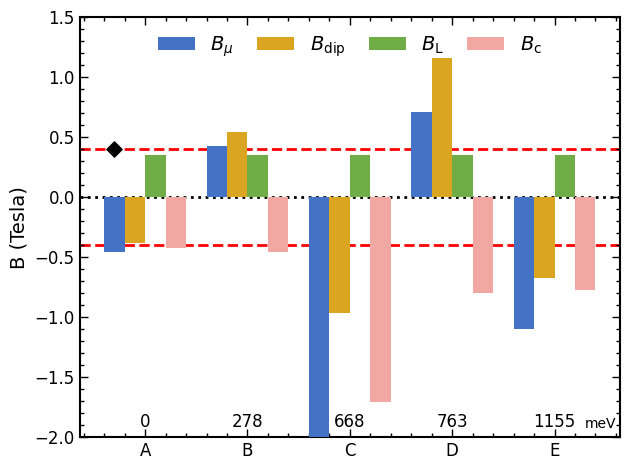

In [22]:
fig, ax = plt.subplots(figsize=None)

sidx = [0, 2, 3, 4, 5]
labels = df_all['label'].to_numpy()[sidx]
labels = ['A', 'B', 'C', 'D', 'E']  # reorder label because of selections
ax = field_bar(
    ax,
    labels=labels,
    B_tot=df_all['Btot_z'].to_numpy()[sidx],
    B_dip=df_all['Bdip_z'].to_numpy()[sidx], # only dip no lor
    # B_dip=df_all['Bdip_tot_z'].to_numpy()[sidx],   # dip+lor
    B_lor=df_all['Blor_z'].to_numpy()[sidx],
    B_con=df_all['Bcon_z'].to_numpy()[sidx],
    energy=df_all['delta_E'].to_numpy()[sidx],
    e_ypos=-1.95,
    e_font=12,
    B_exp=0.3963,
    be_color='k',
    g_width=0.2,
    bar_width=0.2
)

ax.axhline(y=0.0, ls='dotted', lw=2, color='k', zorder=0)
ax.axhline(y=-0.3963, ls='dashed', lw=2, color='r', zorder=0)
ax.axhline(y=+0.3963, ls='dashed', lw=2, color='r', zorder=0)

ax.set_ylabel(r'B (Tesla)', fontsize=14)

ax.set_ylim([-2.00, 1.50])
ax.legend(frameon=False)
ax.legend(
    loc="upper center", bbox_to_anchor=(0.5, 1.001), fontsize=14,
    ncol=4, frameon=False, handlelength=1.9, columnspacing=1.2,
)

style_axes(ax)

plt.tight_layout()
figname='Fe2P_muonfield_contributions.png'
figname=os.path.join(dpath, figname)
plt.savefig(figname)
plt.show()

# ENERGY: value text in meV; and set a y-axis point to put it, default = 0
# EXP FIELDS: markers; should always be at center of B_mu, what if for multiple observed fields?
# FIGURE STYLINE...

In [23]:
file = 'r2.in'
file = os.path.join(folder, file)
inp_ase  = read_from_file(file, format="espresso-in")
inp_ase2 = inp_ase.copy() 

In [24]:
file = 'r2.out'
file = os.path.join(folder, file)
rlx_ase  = read_from_file(file, format="espresso-out", index=-1)
rlx_ase2 = rlx_ase.copy()

In [25]:
# get and remove muon position
rlx_ase2 =  rlx_ase.copy()
if 1 not in rlx_ase2.numbers:
    raise ValueError("No Hydrogen (atomic number 1) found in rlx_ase2.")
mu_idx = np.where(rlx_ase2.numbers == 1)[0][-1]
mupos_rlx = rlx_ase2.get_scaled_positions()[mu_idx]
del rlx_ase2[mu_idx]

mupos_rlx

array([0.00113802, 0.16409303, 0.16666813])

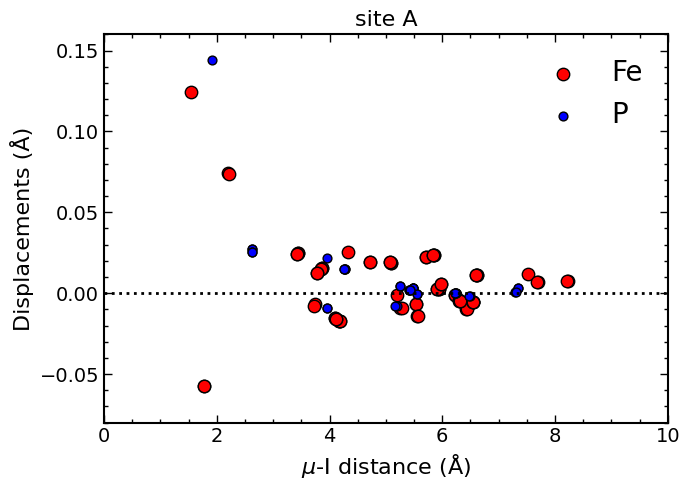

In [26]:
radial_res = radial_to_dict(inp_ase.copy(), rlx_ase.copy(), muon_label='H')


fontsize=16
fig, ax = plt.subplots(figsize=(7, 5))

specie='Fe'
sel = select_radial_displacement(
    radial_res,
    species=specie,
    distance_type='unperturbed',
    # cutoff=6.0,          # None -> no cutoff, keep everything
)
ax.scatter(
    sel['distance'], sel['displacements'], color='red', s=80, 
    edgecolor='k', label=specie, zorder=1,
    )

specie='P'
sel = select_radial_displacement(
    radial_res,
    species=specie,
    distance_type='unperturbed',
    # cutoff=6.0,          # None -> no cutoff, keep everything
)
ax.scatter(
    sel['distance'], sel['displacements'], color='blue', s=40, 
    edgecolor='k', label=specie, zorder=2
    )

# ax.set_title(r'Fe$_2$P: 2x2x3 supercell', fontsize=fontsize)
ax.set_title(r'site A', fontsize=fontsize)
ax.set_xlabel(r'$\mu$-I distance (Å)', fontsize=fontsize)
ax.set_ylabel(r'Displacements (Å)' , fontsize=fontsize)

ax.set_xlim([-0.00, 10.0])
ax.set_ylim([-0.08, 0.16])
ax.axhline(y=0.0, ls='dotted', lw=2, color='k')

ax.legend(frameon=False)
ax.legend(
    loc="best", fontsize=fontsize+4, ncol=1,
    frameon=False, handlelength=1.9, columnspacing=1.2,
)
style_axes(ax, fontsize=fontsize-2)


plt.tight_layout()
figname='Fe2P_siteA_displacements.png'
figname=os.path.join(dpath, figname)
plt.savefig(figname)
plt.show()

In [27]:
max_displacement(inp_ase.copy(), rlx_ase.copy())

np.float64(0.14440543677997847)